# 05 · A Gaussian-process primer (with `pyrox`)

A **Gaussian process** (GP) is a prior over smooth functions: nearby inputs get
correlated outputs, with the correlation set by a **kernel**. It is the natural
way to say *"the extreme-value parameters vary smoothly across space"*.

As a warm-up, forget extremes for a moment and just use a GP to **interpolate** a
spatial field: regress each station's *mean annual maximum* onto its
`(lon, lat)`, and predict a smooth surface with uncertainty. We use `pyrox.gp`:
a `Matern` kernel, a `GPPrior`, fit its hyperparameters by SVI, then `condition`
on the data and `predict` on a grid.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, autoguide
from pyrox.gp import GPPrior, Matern, gp_factor

from spatial_extremes import data
from spatial_extremes.data import IBERIA_BBOX

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
X = jnp.asarray(stations)                 # (S, 2) lon/lat
y = jnp.asarray(np.nanmean(maxima, 1))           # mean annual max per station
# standardise inputs and target for stable GP fitting
Xm, Xs = X.mean(0), X.std(0)
Xn = (X - Xm) / Xs
ym, ysd = float(y.mean()), float(y.std())
yn = (y - ym) / ysd
noise_var = jnp.array(0.05)
print("source:", "REAL" if is_real else "SYNTHETIC", "| stations", X.shape[0])

source: REAL | stations 63


In [4]:
def model(Xn, yn, noise_var):
    k = Matern(nu=1.5)
    k.set_prior("variance", ndist.LogNormal(0.0, 1.0))
    k.set_prior("lengthscale", ndist.LogNormal(0.0, 1.0))
    gp_factor("obs", GPPrior(kernel=k, X=Xn), yn, noise_var)

guide = autoguide.AutoNormal(model)
svi = SVI(model, guide, numpyro.optim.Adam(5e-2), Trace_ELBO())
res = svi.run(jr.PRNGKey(0), 1500, Xn, yn, noise_var, progress_bar=False)

def fitted(name):
    key = next(k for k in res.params if name in k and k.endswith("_auto_loc"))
    return float(jnp.exp(res.params[key]))

var_fit, ls_fit = fitted("variance"), fitted("lengthscale")
print(f"fitted kernel: variance={var_fit:.2f}, lengthscale={ls_fit:.2f}")

fitted kernel: variance=1.13, lengthscale=0.21


Condition the fitted GP on the stations and predict on a regular grid over Iberia:

In [5]:
lon_min, lon_max, lat_min, lat_max = IBERIA_BBOX
glon = np.linspace(lon_min, lon_max, 60)
glat = np.linspace(lat_min, lat_max, 60)
GX, GY = np.meshgrid(glon, glat)
grid = np.stack([GX.ravel(), GY.ravel()], axis=1)
gridn = (jnp.asarray(grid) - Xm) / Xs

k = Matern(nu=1.5, init_variance=var_fit, init_lengthscale=ls_fit)
prior = GPPrior(kernel=k, X=Xn)
with numpyro.handlers.seed(rng_seed=0):
    cond = prior.condition(yn, noise_var)
    mean, var = cond.predict(gridn)

mean_field = np.asarray(mean) * ysd + ym
std_field = np.sqrt(np.asarray(var)) * ysd

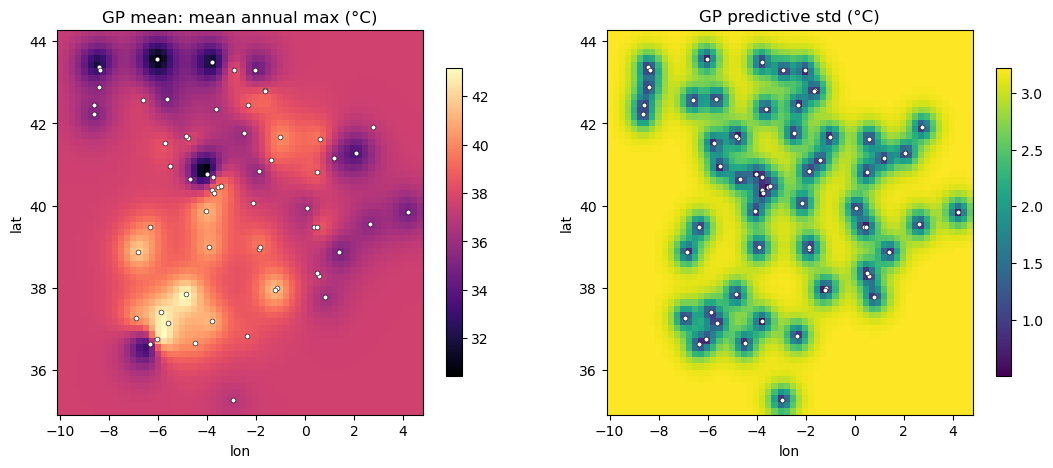

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, field, title, cmap in [
    (axes[0], mean_field, "GP mean: mean annual max (°C)", "magma"),
    (axes[1], std_field, "GP predictive std (°C)", "viridis"),
]:
    pc = ax.pcolormesh(GX, GY, field.reshape(GX.shape), cmap=cmap, shading="auto")
    ax.scatter(stations[:, 0], stations[:, 1], c="w", s=12, edgecolor="k", linewidth=0.4)
    fig.colorbar(pc, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.show()

The GP gives a smooth interpolated surface **and** a calibrated uncertainty that
grows away from stations. **Next:** instead of interpolating a precomputed
summary, we put a GP *inside* the GEV model so the location parameter $\mu(s)$ is
a latent spatial field learned jointly with the tail.